In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
μ0 = 4*np.pi*1e-7 #Permeabilidade magnética do vácuo
N, g, l, lc, d, m, k, R, V, x0 = 1000, 0.002, 0.04, 0.70, 0.04, 0.1, 100, 2, 39.46, 0.03
lg = 2*g
x_min = 0.0
# Tabela BxH
H_data = np.array([0,68,135,203,271,338,406,474,542,609,1100,1500,2500,4000,5000,9000,12000,20000,25000], dtype=float)
B_data = np.array([0,0.733,1.205,1.424,1.517,1.560,1.588,1.617,1.631,1.646,1.689,1.703,1.724,1.731,1.738,1.761,1.770,1.80,1.816], dtype=float)
H_interp = interp1d(B_data, H_data, kind='cubic', fill_value="extrapolate")

In [2]:
def Ag(x):
    x_safe = np.maximum(1e-6, np.minimum(x, d*0.999))
    return l * (d - x_safe)

def An(x):
    x_safe = np.maximum(x_min, x)
    return l*(d - 0.5*x_safe)

In [3]:
# Essa função calcula a "energia guardada" no ímã (Coenergia)
def coenergia_total(B, x):
    # Cria uma listinha de 0 até o valor atual do Fluxo (B) com 100 pedacinhos
    B_integr = np.linspace(0, B, 100)

    # Olha na tabela BxH para ver qual o esforço (H) o ferro faz para cada pedaço de B
    H_vals = H_interp(B_integr)

    # Faz a conta da corrente (i) somando o que se perde no ferro e o que se perde no ar
    # i = (Perda no Ferro + Perda no Ar) / Número de voltas da bobina
    i_vals = (H_vals*lc + (B_integr*An(x)*lg)/(μ0*Ag(x))) / N

    # Soma todas as áreas desses 100 pedacinhos para achar a energia total
    # O trapézio serve para calcular a área embaixo da curva do gráfico Corrente vs Fluxo
    return np.trapezoid(i_vals * N * An(x), B_integr)

In [4]:
def plot_simples(t, x, B, i, Fm, titulo, cor):
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs[0,0].plot(t, x*100, cor); axs[0,0].set_title("Posição (cm)")
    axs[0,1].plot(t, B, cor); axs[0,1].set_title("Densidade de Fluxo (T)"); axs[0,1].set_ylim(0, 7)
    axs[1,0].plot(t, i, cor); axs[1,0].set_title("Corrente (A)"); axs[1,0].set_ylim(0, 20)
    axs[1,1].plot(t, Fm, cor); axs[1,1].set_title("Força (N)"); axs[1,1].set_ylim(-2500, 100)
    for ax in axs.flat: ax.grid(True)
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()

MODELO IDEAL

In [5]:

t_final =
t_eval = np.linspace(0, t_final, 6000)


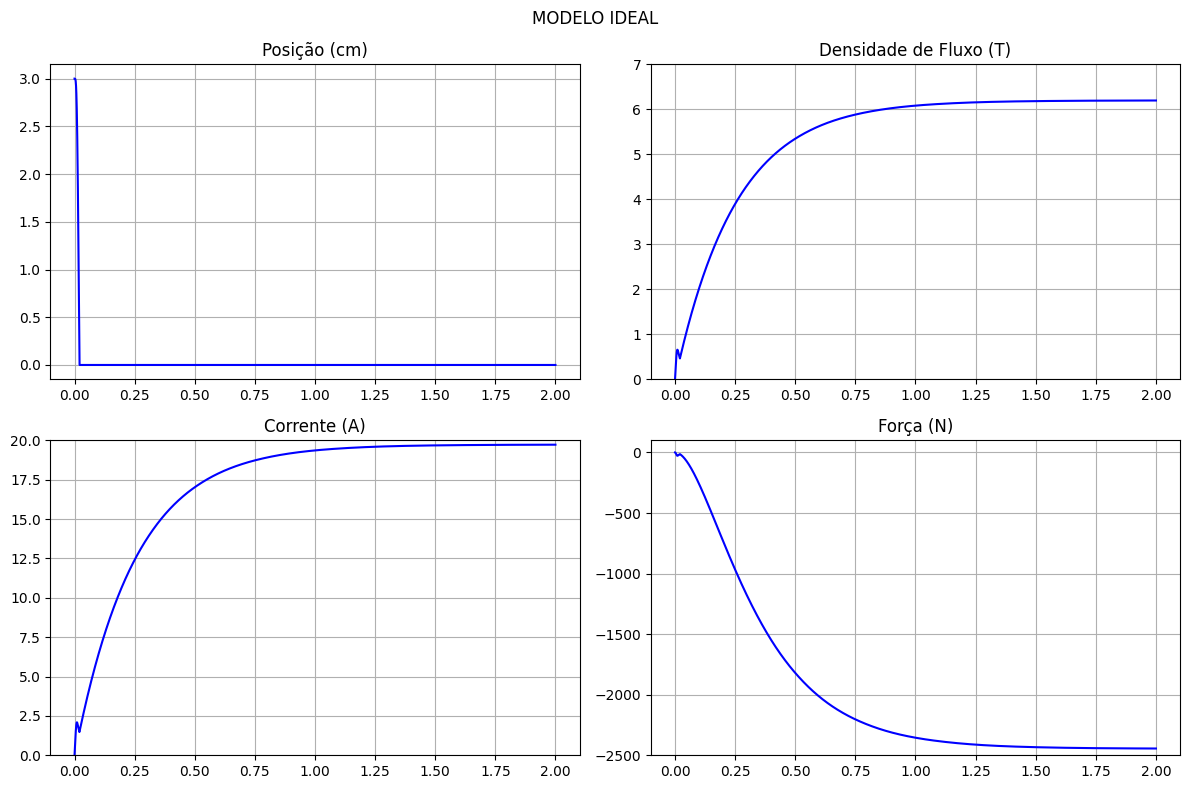

In [6]:
def sistema1(t, X):
    x, v, i = X
    if x <= 0: x, v = 0, 0
    #A indutância muda com a posição, mas ignora o ferro
    L = (μ0 * N**2 * l * (d - np.clip(x, 0, d*0.999))) / lg
    dLdx = - μ0 * N**2 * l / lg
    #Força calculada puramente pela variação da indutância
    Fm = 0.5 * i**2 * dLdx
    #Baseado na Lei de Faraday
    didt = (V - R*i - i*dLdx*v) / L
    dvdt = (Fm - k*(x - x0)) / m
    if x <= 0 and dvdt < 0: dvdt = 0
    return [v, dvdt, didt]


sol1 = solve_ivp(sistema1, (0, t_final), [x0, 0, 0], t_eval=t_eval, method="Radau")
B1 = μ0 * N * sol1.y[2] / lg
Fm1 = 0.5 * sol1.y[2]**2 * (-μ0 * N**2 * l / lg)

plot_simples(sol1.t, sol1.y[0], B1, sol1.y[2], Fm1, "MODELO IDEAL", "blue")

MODELO LINEAR


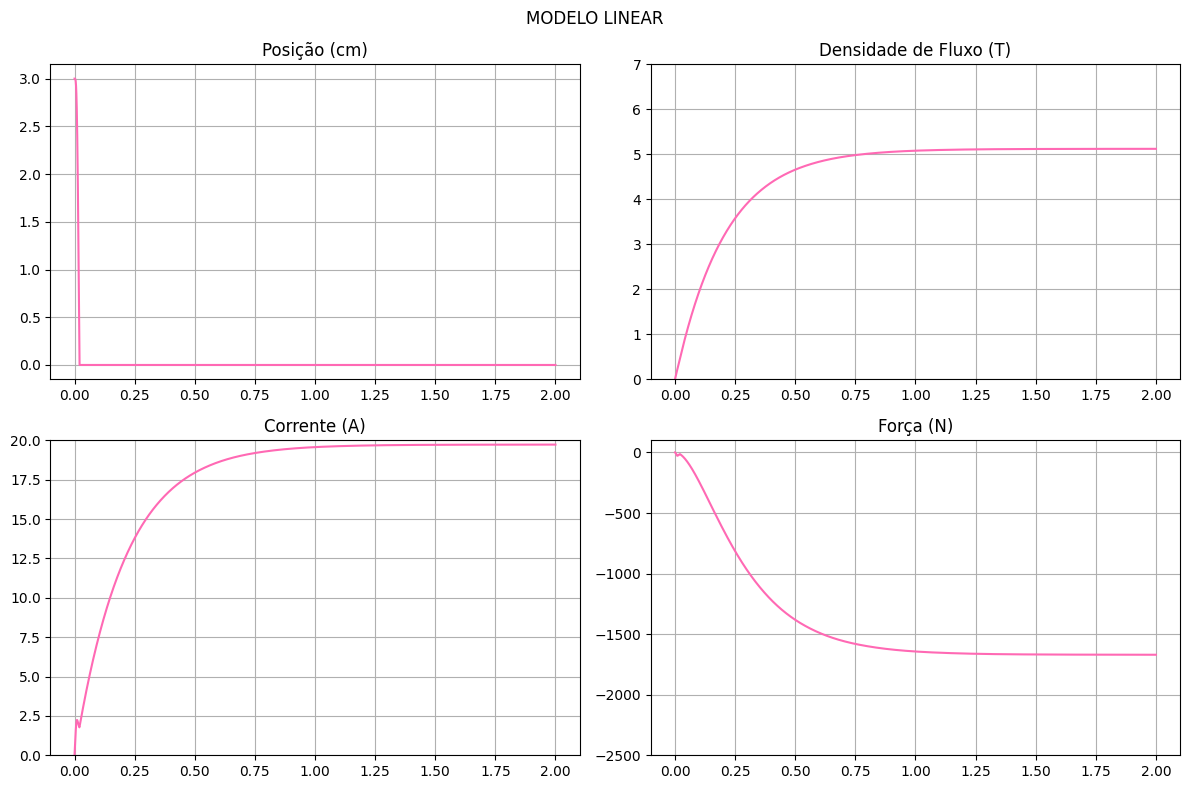

In [7]:
H1_lin, Bp1_lin, H2_lin, Bp2_lin = 135, 1.205, 542, 1.631
μeq = (Bp2_lin-Bp1_lin)/(H2_lin-H1_lin)#Calcula uma permeabilidade média constante para o ferro
Rn = lc / (μeq * l * d)

def sistema2(t, X):
    x, v, i = X
    if x <= 0: x, v = 0, 0
    Rg = lg / (μ0 * l * (d - np.clip(x, 0, d*0.999)))
    L = (N**2) / (Rn + Rg)
    dLdx = -N**2 * lg * μ0 * l / (((Rn * μ0 * l * (d - np.clip(x, 0, d*0.999))) + lg)**2)
    Fm = 0.5 * i**2 * dLdx
    didt = (V - R*i - i*dLdx*v) / L
    dvdt = (Fm - k*(x - x0)) / m
    if x <= 0 and dvdt < 0: dvdt = 0
    return [v, dvdt, didt]

sol2 = solve_ivp(sistema2, (0, t_final), [x0, 0, 0], t_eval=t_eval, method="Radau")
B2 = N * sol2.y[2] / ((Rn + (lg / (μ0 * l * (d - np.clip(sol2.y[0], 0, d*0.999))))) * l * d)
# Força calculada com a derivada de L para o linear
Fm2 = []
for xi, ii in zip(sol2.y[0], sol2.y[2]):
    dL = -N**2 * lg * μ0 * l / (((Rn * μ0 * l * (d - np.clip(xi, 0, d*0.999))) + lg)**2)
    Fm2.append(0.5 * ii**2 * dL)

plot_simples(sol2.t, sol2.y[0], B2, sol2.y[2], Fm2, "MODELO LINEAR", "hotpink")

MODELO REAL

In [8]:
def system(t, y):

    # Pega o que temos agora: Fluxo, Onde ele está e a Velocidade
    Bn = y[0]
    x  = y[1]
    v  = y[2]

    # 1. Descobre qual a corrente que tá passando no fio agora
    Hn = float(H_interp(Bn))

    parte_nucleo = Hn * lc
    parte_gap = (Bn * An(x) * lg) / (μ0 * Ag(x))

    i = (parte_nucleo + parte_gap) / N

    # 2. Calcula o "puxão" do ímã (Força Magnética)
    # Ele faz um teste: "Se eu mexer só um tiquinho, a energia muda quanto?"
    dx_s = 1e-5

    W_p = coenergia_total(Bn, x + dx_s)
    W_m = coenergia_total(Bn, x - dx_s)

    # Esse resultado é a força do puxão
    Fm = -(W_p - W_m) / (2 * dx_s)

    # 3. Calcula o empurrão da mola (ela quer levar o bloco de volta)
    Fel = -k * (x - x0)

    # 4. Avisa pro programa como as coisas devem mudar:

    # Como o fluxo aumenta ou diminui
    dBn_dt = (V - R*i) / (N * An(x))

    # A velocidade diz pra onde ele anda
    dx_dt = v

    # A briga entre o ímã e a mola faz ele acelerar
    dv_dt = (Fm - Fel) / m

    return [dBn_dt, dx_dt, dv_dt]

In [9]:
# Começa parado e sem nada de fluxo
y0 = [0.0, x0, 0.0]

# Vai fingir que passou 2 segundos
T_final = 2

# Cria 6 mil pontinhos no tempo pra desenhar o gráfico
t_eval = np.linspace(0, T_final, 6000)

# resolve todas as contas chatas de uma vez
# usado para descobrir como o sistema evolui
# agora vai acontecer a integração do tempo para obtermos Bn, x, v
#Você retorna as derivadas, e o solve_ivp integra essas derivadas no tempo, gerando os valores de Bn, x e v que aparecem em sol.y
sol = solve_ivp(system,
                [0, T_final],
                y0,
                method='Radau',
                t_eval=t_eval,
                rtol=1e-8,
                atol=1e-10)

# Separa os resultados pra usar
Bn = sol.y[0]
x  = sol.y[1]
v  = sol.y[2]

In [10]:
# O programa lá em cima só guardou Fluxo, Onde ele está e Velocidade.
# Agora a gente tem que calcular na mão a Força e a Corrente de cada momento.

# Cria lista varias pra guardar forças e corrente
F_gap     = np.zeros_like(Bn)
F_nucleo  = np.zeros_like(Bn)
Fm_total  = np.zeros_like(Bn)
i         = np.zeros_like(Bn)

dx_small = 1e-5
# Agora que eu sei Bn e x em cada instante,vou calcular as forças e corrente em cada instante
# Vamos olhar ponto por ponto e fazer a conta de novo:
for k in range(len(Bn)):

    # Força que o ar faz
    F_gap[k] = (Bn[k]**2 * Ag(x[k])) / (2 * μ0)

    # Força que o ferro faz (usando aquela conta da energia)
    W_plus  = coenergia_total(Bn[k], x[k] + dx_small)
    W_minus = coenergia_total(Bn[k], x[k] - dx_small)

    F_nucleo[k] = (W_plus - W_minus) / (2 * dx_small)

    # Soma as duas pra saber o puxão total
    Fm_total[k] = -F_gap[k] - F_nucleo[k]

    # Descobre qual era a corrente nesse momento
    Hn = float(H_interp(Bn[k]))

    parte_nucleo = Hn * lc
    parte_gap = (Bn[k] * An(x[k]) * lg) / (μ0 * Ag(x[k]))

    i[k] = (parte_nucleo + parte_gap) / N

In [11]:
# O batente (Pra não deixar um ferro atravessar o outro)

# Se a conta deu que ele passou do zero, vira zero, bateu
x[x < x_min] = x_min

# Se bateu, a velocidade para na hora
v[x < x_min] = 0

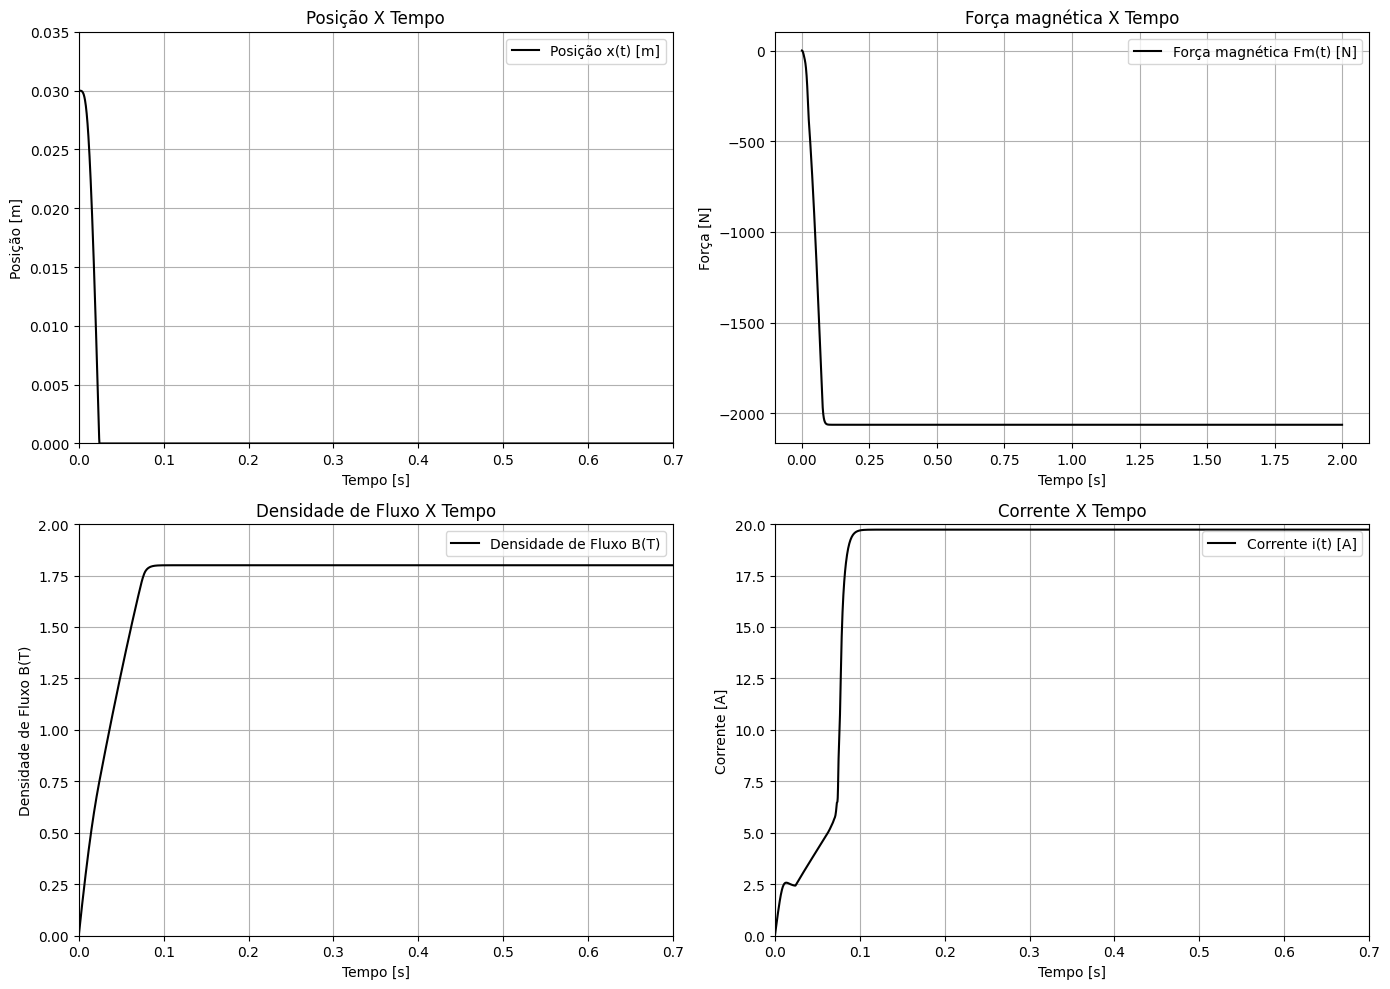

In [12]:
plt.figure(figsize=(14, 10))
tempo_zoom = 0.7

plt.subplot(2, 2, 1)
plt.plot(sol.t, x, color='black', label='Posição x(t) [m]')
plt.title('Posição X Tempo')
plt.xlabel('Tempo [s]')
plt.ylabel('Posição [m]')
plt.xlim([0, tempo_zoom])
plt.ylim([0, 0.035])
plt.grid(True)
plt.legend()


plt.subplot(2, 2, 2)
plt.plot(sol.t, Fm_total, color='black', label='Força magnética Fm(t) [N]')
plt.title('Força magnética X Tempo')
plt.xlabel('Tempo [s]')
plt.ylabel('Força [N]')
plt.grid(True)
plt.legend()


plt.subplot(2, 2, 3)
plt.plot(sol.t, Bn, color='black', label='Densidade de Fluxo B(T)')
plt.title("Densidade de Fluxo X Tempo")
plt.xlabel('Tempo [s]')
plt.ylabel('Densidade de Fluxo B(T)')
plt.xlim([0, tempo_zoom])
plt.ylim([0, 2.0])
plt.grid(True)
plt.legend()


plt.subplot(2, 2, 4)
plt.plot(sol.t, i, color='black', label='Corrente i(t) [A]')
plt.title('Corrente X Tempo')
plt.xlabel('Tempo [s]')
plt.ylabel('Corrente [A]')
plt.xlim([0, tempo_zoom])
plt.ylim([0, 20])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

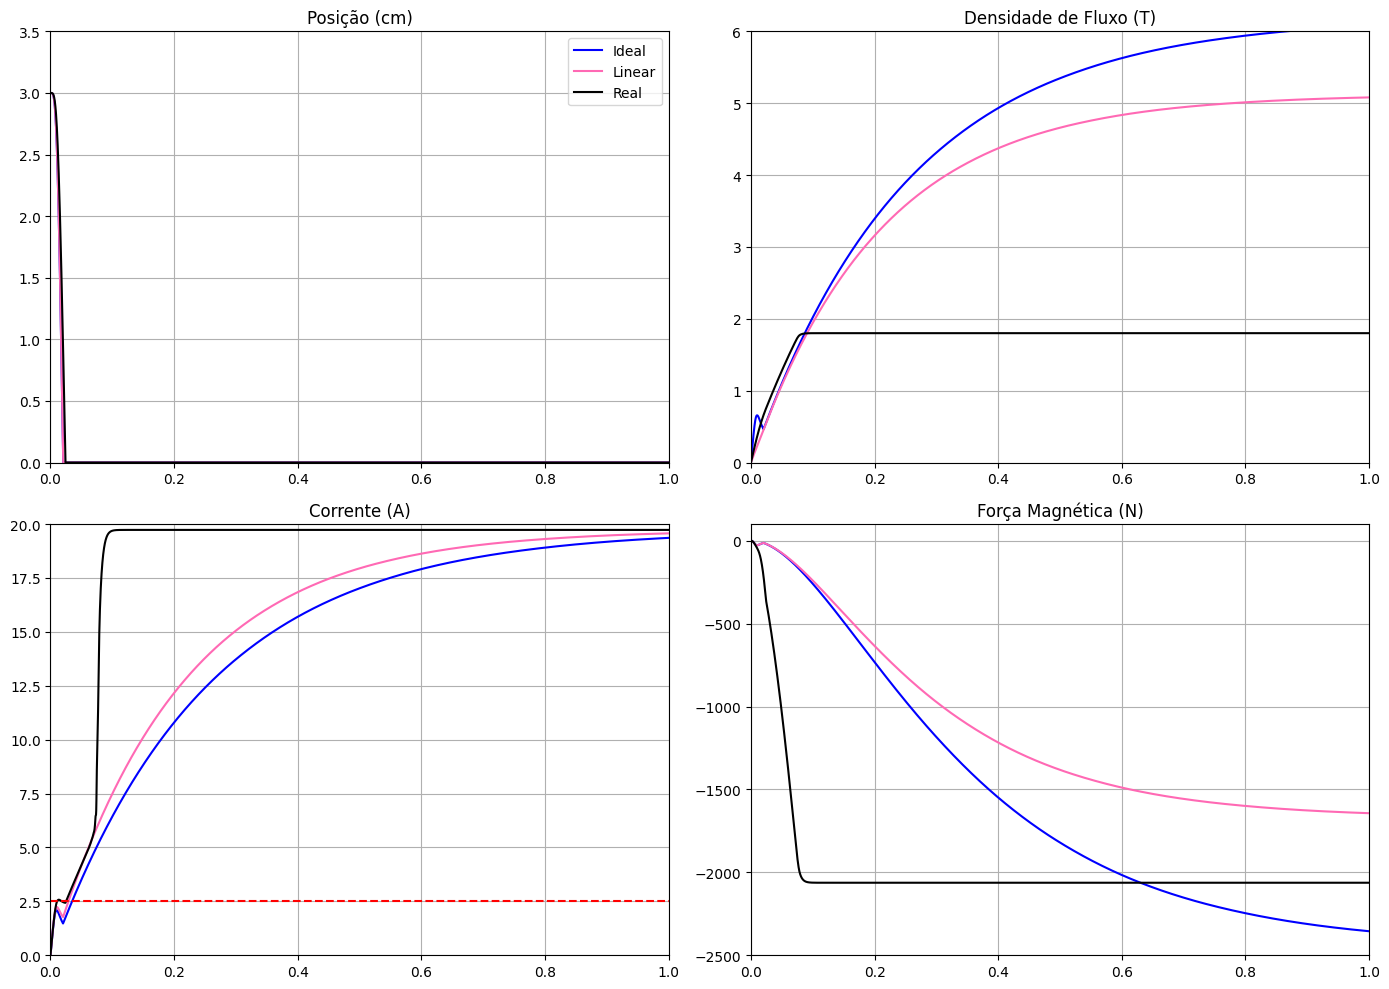

In [13]:

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# AJUSTE O ZOOM AQUI
tempo_zoom = 1.0

# 1. POSIÇÃO (cm)
axs[0,0].plot(sol1.t, sol1.y[0]*100, 'blue', label='Ideal')
axs[0,0].plot(sol2.t, sol2.y[0]*100, 'hotpink', label='Linear')
axs[0,0].plot(sol.t, x*100, 'black', label='Real')
axs[0,0].set_title("Posição (cm)")
axs[0,0].set_xlim([0, tempo_zoom]) # ZOOM NO TEMPO
axs[0,0].set_ylim([0, 3.5])        # ZOOM NA ALTURA (3.5cm)
axs[0,0].legend()
axs[0,0].grid(True)

# 2. FLUXO (T)
axs[0,1].plot(sol1.t, B1, 'blue')
axs[0,1].plot(sol2.t, B2, 'hotpink')
axs[0,1].plot(sol.t, Bn, 'black')
axs[0,1].set_title("Densidade de Fluxo (T)")
axs[0,1].set_xlim([0, tempo_zoom]) # ZOOM NO TEMPO
axs[0,1].set_ylim([0, 6.0])        # ZOOM NA ALTURA (Saturação em 1.8)
axs[0,1].grid(True)

# 3. CORRENTE (A)
axs[1,0].plot(sol1.t, sol1.y[2], 'blue')
axs[1,0].plot(sol2.t, sol2.y[2], 'hotpink')
axs[1,0].plot(sol.t, i, 'black')
axs[1,0].axhline(2.5, color='red', linestyle='--', label='Ref 2.5A')
axs[1,0].set_title("Corrente (A)")
axs[1,0].set_xlim([0, tempo_zoom]) # ZOOM NO TEMPO
axs[1,0].set_ylim([0, 20])         # ZOOM NA ALTURA
axs[1,0].grid(True)

# 4. FORÇA (N) - Aqui a força do Real ('black') aparecerá negativa
axs[1,1].plot(sol1.t, Fm1, 'blue')
axs[1,1].plot(sol2.t, Fm2, 'hotpink')
axs[1,1].plot(sol.t, Fm_total, 'black')
axs[1,1].set_title("Força Magnética (N)")
axs[1,1].set_xlim([0, tempo_zoom]) # ZOOM NO TEMPO
axs[1,1].set_ylim([-2500, 100])
axs[1,1].grid(True)


plt.tight_layout()
plt.show()

In [14]:
def calcular_balanco_energia(sol_data, k_valor, nome):
    # 1. Extração dos dados da simulação
    # sol_data.y[0] = Bn (Fluxo), y[1] = x (Posição), y[2] = v (Velocidade)
    Bn_local = sol_data.y[0]
    x_local = sol_data.y[1]
    v_local = sol_data.y[2]
    t_local = sol_data.t

    # 2. Identificar o índice do impacto (primeira vez que x <= 0)
    idx = np.where(x_local <= 1e-6)[0][0]

    # --- CÁLCULO DAS ENERGIAS NO INSTANTE DO IMPACTO ---

    # A. Energia Cinética (Ec = 1/2 * m * v^2)
    # Pegamos o índice [idx-1] porque no [idx] a velocidade já foi zerada no código
    v_antes = v_local[idx-1]
    E_cinetica = 0.5 * m * (v_antes**2)

    # B. Energia Magnética (Coenergia armazenada no campo)
    E_magnetica = coenergia_total(Bn_local[idx], x_local[idx])

    # C. Energia Dissipada no Resistor (Integral de R * i^2 dt)
    # Calculamos a corrente i para todo o percurso até o impacto
    H_inst = H_interp(Bn_local[:idx+1])
    i_inst = (H_inst*lc + (Bn_local[:idx+1]*An(x_local[:idx+1])*lg)/(μ0*Ag(x_local[:idx+1]))) / N
    E_resistor = np.trapezoid(R * (i_inst**2), t_local[:idx+1])

    # D. Energia Total
    E_total = E_cinetica + E_magnetica + E_resistor

    print(f"--- {nome} (k = {k_valor} N/m) ---")
    print(f"Energia Cinética:  {E_cinetica:.6f} J")
    print(f"Energia Magnética: {E_magnetica:.6f} J")
    print(f"Energia Resistor:  {E_resistor:.6f} J")
    print(f"ENERGIA TOTAL:     {E_total:.6f} J\n")
    return E_total

# --- EXECUÇÃO ---

# Questão 1: Modelo Real (k = 100)
E_diss_1 = calcular_balanco_energia(sol, 100, "RESULTADO IMPACTO REAL")

# Questão 2: Modelo com mola 1 kN/m
k_original = 100
globals()['k'] = 1000 # Altera para 1000 para a nova simulação
sol_k1000 = solve_ivp(system, [0, T_final], y0, method='Radau', t_eval=t_eval)
E_diss_2 = calcular_balanco_energia(sol_k1000, 1000, "RESULTADO IMPACTO 1kN/m")
globals()['k'] = k_original # Restaura o original

--- RESULTADO IMPACTO REAL (k = 100 N/m) ---
Energia Cinética:  0.317911 J
Energia Magnética: 1.469882 J
Energia Resistor:  0.231057 J
ENERGIA TOTAL:     2.018851 J

--- RESULTADO IMPACTO 1kN/m (k = 1000 N/m) ---
Energia Cinética:  0.683385 J
Energia Magnética: 1.252493 J
Energia Resistor:  0.192504 J
ENERGIA TOTAL:     2.128382 J

